# Task 2 — Descriptive Analysis

**Project:** Analysis of Bag Tax Data in U.S. Stores  
**Course:** MGT 8180 — Sustainable Management Analytics  
**Student:** Osman Fatih Karaca  
**Dataset:** Cleaned Montgomery County Bag Tax data (71,780 records, 2012–2024)

---

## Objectives

1. Calculate key summary statistics for **Bag Count**
2. Identify the **top 10 vendors** by Bag Count and Amount Collected
3. Create **two visualizations** that highlight insights from the data

## Tools used
- **Python (pandas, matplotlib)**
- **Jupyter Notebook in VS Code**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CLEANED dataset from Task 1
df = pd.read_csv('../../Data/clean/Bag_Tax_Clean.csv')

# Convert date columns back to datetime (CSV doesn't preserve types)
df['Date From'] = pd.to_datetime(df['Date From'])
df['Date To'] = pd.to_datetime(df['Date To'])

# Quick confirmation
print(f"✅ Loaded cleaned dataset")
print(f"   Records: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Date range: {df['Date From'].min().date()} to {df['Date From'].max().date()}")

✅ Loaded cleaned dataset
   Records: 71,780
   Columns: 14
   Date range: 2012-01-01 to 2024-10-01


In [2]:
# ============================================================
# TASK 2 — Cell 3: Summary statistics for Bag Count
# ============================================================

bag_count = df['Bag Count']

print("=" * 60)
print("BAG COUNT — SUMMARY STATISTICS")
print("=" * 60)
print(f"Total filings (records):    {bag_count.count():,}")
print(f"Total bags reported:        {bag_count.sum():,}")
print()
print(f"Mean (average):             {bag_count.mean():,.2f}")
print(f"Median (middle value):      {bag_count.median():,.2f}")
print(f"Standard deviation:         {bag_count.std():,.2f}")
print()
print(f"Minimum:                    {bag_count.min():,}")
print(f"25th percentile (Q1):       {bag_count.quantile(0.25):,.0f}")
print(f"50th percentile (Q2/median):{bag_count.quantile(0.50):,.0f}")
print(f"75th percentile (Q3):       {bag_count.quantile(0.75):,.0f}")
print(f"Maximum:                    {bag_count.max():,}")
print()
print(f"Skewness:                   {bag_count.skew():.2f}")
print(f"Range (max - min):          {bag_count.max() - bag_count.min():,}")

BAG COUNT — SUMMARY STATISTICS
Total filings (records):    71,780
Total bags reported:        843,798,620

Mean (average):             11,755.34
Median (middle value):      1,160.00
Standard deviation:         70,905.87

Minimum:                    0
25th percentile (Q1):       262
50th percentile (Q2/median):1,160
75th percentile (Q3):       3,591
Maximum:                    2,134,035

Skewness:                   14.91
Range (max - min):          2,134,035


In [3]:
# ============================================================
# TASK 2 — Cell 4: Top 10 vendors
# ============================================================

# Group by Vendor Name, sum Bag Count and Amount Collected
vendor_summary = df.groupby('Vendor Name').agg(
    Bag_Count=('Bag Count', 'sum'),
    Amount_Collected=('Amount Collected', 'sum'),
    Filings=('File ID', 'count')
).reset_index()

# Sort by Bag Count, take top 10
top10_bags = vendor_summary.sort_values('Bag_Count', ascending=False).head(10)
top10_bags_display = top10_bags.copy()
top10_bags_display['Bag_Count'] = top10_bags_display['Bag_Count'].apply(lambda x: f"{x:,}")
top10_bags_display['Amount_Collected'] = top10_bags_display['Amount_Collected'].apply(lambda x: f"${x:,.2f}")

print("=" * 80)
print("TOP 10 VENDORS BY BAG COUNT")
print("=" * 80)
print(top10_bags_display.to_string(index=False))
print()

# Sort by Amount Collected, take top 10
top10_amount = vendor_summary.sort_values('Amount_Collected', ascending=False).head(10)
top10_amount_display = top10_amount.copy()
top10_amount_display['Bag_Count'] = top10_amount_display['Bag_Count'].apply(lambda x: f"{x:,}")
top10_amount_display['Amount_Collected'] = top10_amount_display['Amount_Collected'].apply(lambda x: f"${x:,.2f}")

print("=" * 80)
print("TOP 10 VENDORS BY AMOUNT COLLECTED")
print("=" * 80)
print(top10_amount_display.to_string(index=False))
print()

# How concentrated is the dataset?
total_bags = df['Bag Count'].sum()
top10_bags_total = top10_bags['Bag_Count'].sum()
print(f"📊 Top 10 vendors account for {top10_bags_total / total_bags * 100:.1f}% of all bags reported")
print(f"   ({top10_bags_total:,} of {total_bags:,})")

TOP 10 VENDORS BY BAG COUNT
                  Vendor Name   Bag_Count Amount_Collected  Filings
       Giant of Maryland, LLC 189,483,690    $9,474,184.50      155
       NAI Saturn Eastern LLC  75,230,038    $3,761,501.90      118
 Whole Foods Market Group Inc  42,362,892    $2,118,144.60      154
           Target Corporation  37,466,679    $1,873,333.95      157
                Harris Teeter  30,656,987    $1,532,849.35      154
         Trader Joe's Company  25,554,407    $1,277,720.35      153
          Wal-Mart Stores Inc  24,635,922    $1,231,796.10      151
                Safeway, Inc.  22,861,366    $1,143,068.30       38
Maryland CVS Pharmacy, L.L.C.  22,838,259    $1,141,912.95      155
             DOS FRIENDS INC.  17,508,308      $875,415.40      178

TOP 10 VENDORS BY AMOUNT COLLECTED
                  Vendor Name   Bag_Count Amount_Collected  Filings
       Giant of Maryland, LLC 189,483,690    $9,474,184.50      155
       NAI Saturn Eastern LLC  75,230,038    $3,761,

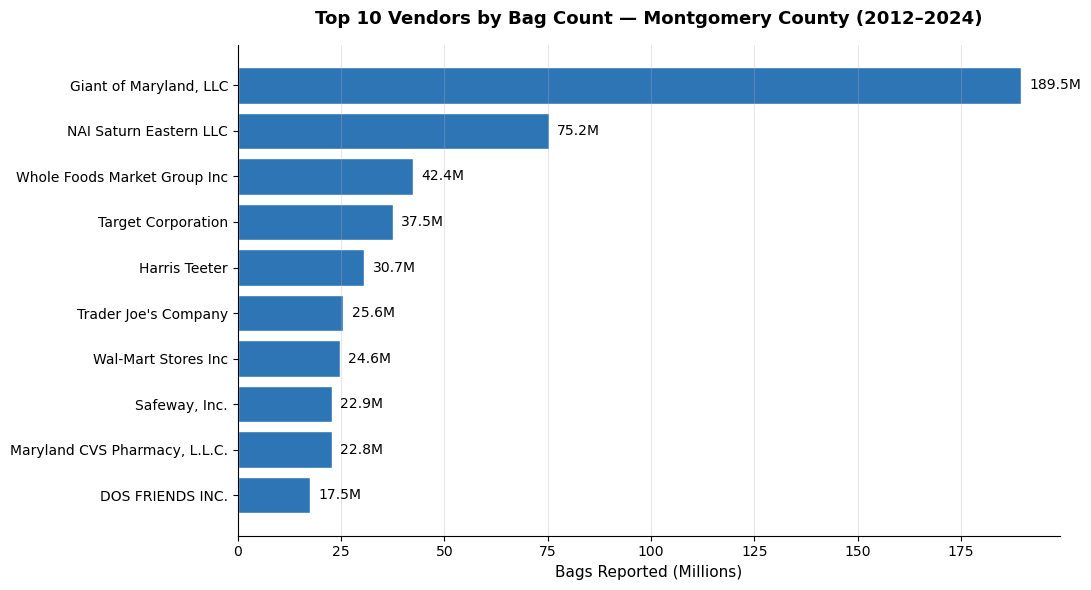

 Chart saved to Outputs/Charts/chart_top10_vendors.png


In [9]:
# ============================================================
# TASK 2 — Cell 5: Visualization 1 — Top 10 Vendors Bar Chart
# ============================================================

# Use the top10_bags table from Cell 4
chart_data = top10_bags.sort_values('Bag_Count', ascending=True)  # ascending for horizontal bar

# Create the figure
fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar chart
bars = ax.barh(chart_data['Vendor Name'], chart_data['Bag_Count'] / 1_000_000,
               color='#2E75B6', edgecolor='white')

# Labels and title
ax.set_xlabel('Bags Reported (Millions)', fontsize=11)
ax.set_title('Top 10 Vendors by Bag Count — Montgomery County (2012–2024)',
             fontsize=13, fontweight='bold', pad=15)

# Add value labels at the end of each bar
for bar, value in zip(bars, chart_data['Bag_Count'] / 1_000_000):
    ax.text(value + 2, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}M', va='center', fontsize=10)

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_top10_vendors.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved to Outputs/Charts/chart_top10_vendors.png")

In [8]:
import os

# Create the Outputs/Charts folder if it doesn't exist
output_folder = '../../Outputs/Charts'
os.makedirs(output_folder, exist_ok=True)
print(f"✅ Folder ready: {output_folder}")

✅ Folder ready: ../../Outputs/Charts


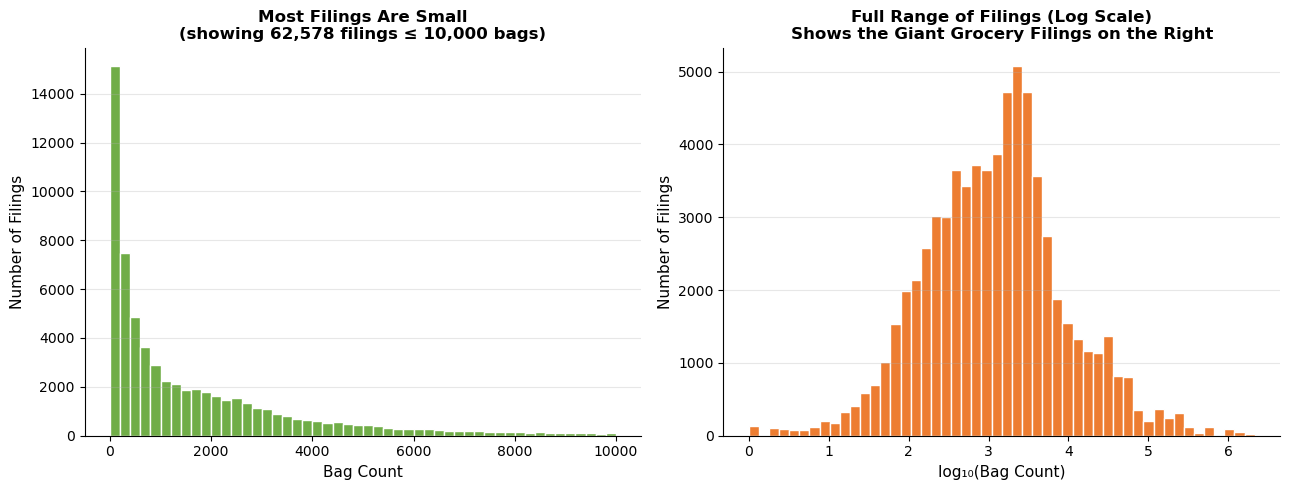

 Chart saved to Outputs/Charts/chart_distribution.png


In [10]:
# ============================================================
# TASK 2 — Cell 6: Visualization 2 — Distribution of Bag Counts
# ============================================================

# We'll build a 2-panel chart:
# Left:  small/medium filings (≤ 10,000 bags) on a normal scale
# Right: ALL filings on a log scale (so the giant ones don't squash everything)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- LEFT PANEL: Filings with Bag Count ≤ 10,000 ---
small_filings = df[df['Bag Count'] <= 10000]['Bag Count']
axes[0].hist(small_filings, bins=50, color='#70AD47', edgecolor='white')
axes[0].set_xlabel('Bag Count', fontsize=11)
axes[0].set_ylabel('Number of Filings', fontsize=11)
axes[0].set_title(f'Most Filings Are Small\n(showing {len(small_filings):,} filings ≤ 10,000 bags)',
                  fontsize=12, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# --- RIGHT PANEL: ALL filings, log scale ---
nonzero = df[df['Bag Count'] > 0]['Bag Count']
axes[1].hist(np.log10(nonzero), bins=50, color='#ED7D31', edgecolor='white')
axes[1].set_xlabel('log₁₀(Bag Count)', fontsize=11)
axes[1].set_ylabel('Number of Filings', fontsize=11)
axes[1].set_title('Full Range of Filings (Log Scale)\nShows the Giant Grocery Filings on the Right',
                  fontsize=12, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

# Save and display
plt.tight_layout()
plt.savefig('../../Outputs/Charts/chart_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved to Outputs/Charts/chart_distribution.png")

---

## Task 2 — Summary of Findings

### Bag Count statistics
- **Total bags reported:** 843,798,620 across 71,780 filings
- **Mean:** 11,755 bags per filing
- **Median:** 1,160 bags per filing
- **Standard deviation:** 70,906
- **Maximum:** 2,134,035 (a single filing)
- **Skewness:** 14.91 (extremely right-skewed)

The mean is roughly **10× the median** — a clear signal that a small number of high-volume filings dominate the distribution. The skewness of 14.91 confirms this: typical retail data has skewness of 1–3; 14.9 indicates an extreme concentration in the top vendors.

### Top 10 vendors
The top 10 vendors collectively account for **57.9% of all bags reported** (488.6M of 843.8M), even though they represent only **0.6% of vendors** (10 of 1,738). Giant of Maryland alone reports 189.5M bags — **22.5% of total county activity**.

The rankings by Bag Count and Amount Collected are **identical**, because the tax is a flat $0.05 per bag — total revenue is mechanically tied to total bags.

### Notable observation: Safeway → NAI Saturn corporate transition
- **Safeway, Inc.** appears in the top 10 with only **38 filings** (instead of the typical ~150 for active vendors)
- **NAI Saturn Eastern LLC** appears in the top 10 with **118 filings**, starting around 2015

These are the same physical stores filing under different legal entities after the **2015 Albertsons-Safeway merger**. Combined, Safeway operations would total **98.1M bags ($4.9M revenue)**, second only to Giant.

### Visualizations
1. **Top 10 Vendors Bar Chart** — shows the dominance of grocery chains, with Giant clearly in the lead
2. **Distribution of Filings** — two-panel histogram showing that most filings are small (≤10K bags) but a long tail of giant grocery filings extends to over 1 million bags. The log-scale view confirms a roughly log-normal distribution

### Implication for later analysis
This concentration is the central feature of the dataset. Any policy intervention focused on the **top 10 retailers** would touch a **majority of bags county-wide**. We will return to this in Tasks 3, 4, and 5.